# =================================================================
# 🤖 PREDICCIÓN DE ACCIONES CON REDES NEURONALES LSTM

|       |         |
| :--- | :--- |
| **Autor** | Garcy Valenzuela Peña |
| **Versión** | 1.0 (13.3.2026) |
| **Licencia** | MIT |
| **Email** | garcyfx@gmail.com |
| **Notas** | Testeado en PC con Python 3.9.12, VScode |
| **Librerías Test** | yfinance: 1.1.0, pandas: 2.1.4, numpy: 1.26.4, matplotlib: 3.7.5, scikit-learn: 1.6.1, tensorflow: 2.20.0 |
# =================================================================

## 🛠️ Información del Proyecto
### Este script descarga datos financieros, calcula indicadores técnicos, entrena un modelo de Deep Learning y proyecta el precio a 5 días.

#### Nota: Este desarrollo es sólo con fines demostrativos y aprendizaje, de ninguna forma es para realizar una recomendación de inversión.

## Los siguientes activos e indicadores se utilizarán como características para el modelo


### 🏗️ **1. Applied Materials (AMAT)**
**Categoría:** Fabricación de Equipos (Equipamiento Crítico)  
**Descripción:** Es el líder mundial en ingeniería de materiales. AMAT no fabrica los chips finales, sino que construye las máquinas complejas que empresas como TSMC o Intel necesitan para fabricarlos.  
**Importancia en el modelo:** Es nuestro Target (objetivo). Su comportamiento suele ser un indicador adelantado de la capacidad de producción global de chips.

[Sitio Oficial de Applied Materials](https://www.appliedmaterials.com/)


### 🧠 **2. NVIDIA Corporation (NVDA)**
**Categoría:** Diseño de GPU e Inteligencia Artificial  
**Descripción:** El diseñador de chips más valioso del mundo. Sus unidades de procesamiento gráfico (GPU) son el estándar para el entrenamiento de Inteligencia Artificial, centros de datos y videojuegos.  
**Importancia en el modelo:** Actúa como Feature de Impulso. El éxito de NVIDIA genera una reacción en cadena: si NVDA vende más chips, sus fabricantes necesitarán comprar más máquinas a empresas como AMAT.

[Sitio Oficial de NVIDIA](https://www.nvidia.com/es-la/)

### 📈 **3. iShares Semiconductor ETF (SOXX)**
**Categoría:** Índice Diversificado (ETF del Sector)  
**Descripción:** Un fondo que agrupa a las 30 empresas de semiconductores más importantes de EE. UU. Incluye a gigantes como Broadcom, AMD, Intel y Texas Instruments.  
**Importancia en el modelo:** Actúa como Feature de Contexto (Beta). Ayuda a la red neuronal a entender si el movimiento de AMAT es un evento aislado o si es una tendencia general de todo el mercado de semiconductores.

### 💡 Resumen de la Relación

| Activo | Función en el Código | Rol Industrial |
| :--- | :--- | :--- |
| **AMAT** | Variable Objetivo | Proveedor de infraestructura |
| **NVDA** | Indicador de Demanda | Líder en diseño e innovación |
| **SOXX** | Sentimiento de Mercado | Salud general del ecosistema |


### **1. RSI (Índice de Fuerza Relativa)**
Podemos imaginar que el RSI es un "termómetro de velocidad" que va de 0 a 100. Nos dice si una acción ha subido o bajado demasiado rápido.
*   **Sobrecompra (arriba de 70):** La acción está "muy caliente". Ha subido tanto que es probable que pronto la gente empiece a vender y el precio baje.
*   **Sobreventa (debajo de 30):** La acción está "muy fría". Ha bajado tanto que podría estar barata y pronto la gente empiece a comprar, haciendo que el precio suba.

### **2. MACD (Convergencia/Divergencia de Medias Móviles)**
Podemos imaginar al MACD como un "detector de olas". Nos ayuda a saber hacia dónde va la marea (la tendencia) y qué tanta fuerza lleva.
Se compone de dos líneas que se cruzan.
*   **Señal de compra:** Cuando la línea rápida cruza hacia arriba a la lenta, es como si una ola empezara a subir con fuerza.
*   **Señal de venta:** Cuando la línea rápida cruza hacia abajo, la ola está perdiendo fuerza y el precio podría caer.


In [1]:
import os
import sys
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd

import yfinance as yf

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import timedelta

from sklearn.metrics import mean_squared_error,mean_absolute_error

from sklearn.preprocessing import MinMaxScaler, StandardScaler

import tensorflow as tf
from tensorflow.keras import models, layers, callbacks, optimizers, regularizers
from tensorflow.keras.callbacks import Callback
tf.get_logger().setLevel('ERROR')

import logging


In [2]:
# --- CONFIGURACIÓN DE SILENCIO (Para una consola limpia) ---
yf.set_tz_cache_location("cache")
logging.getLogger('yfinance').setLevel(logging.CRITICAL)

# ==============================================================================
# 1. CONFIGURACIÓN Y DESCARGA DE DATOS
# ==============================================================================
tickers = ["AMAT", "NVDA", "SOXX"]
inicio = "2020-01-01"

print(f"\n 📥 Descargando sector Semiconductores: {tickers}...")
try:
    # Descarga de datos
    data_raw = yf.download(tickers, start=inicio, auto_adjust=True)

    # Aplanar MultiIndex si es necesario
    if isinstance(data_raw.columns, pd.MultiIndex):
        data_raw.columns = ['_'.join(col).strip() for col in data_raw.columns.values]

    # Para ver los datos en la consola/terminal:
    print("\n✅ Últimos registros descargados:")
    print(data_raw.tail())

    # Si se usa VS Code Notebooks (.ipynb), se puede usar:
    # display(data_raw.tail())

except Exception as e:
    print(f"❌ Error: {e}")


 📥 Descargando sector Semiconductores: ['AMAT', 'NVDA', 'SOXX']...


[*********************100%***********************]  3 of 3 completed


✅ Últimos registros descargados:
            Close_AMAT  Close_NVDA  Close_SOXX   High_AMAT   High_NVDA  \
Date                                                                     
2026-03-09  338.940002  182.640106  336.369995  339.160004  182.900102   
2026-03-10  345.880005  184.760010  338.809998  355.279999  186.429918   
2026-03-11  351.070007  186.029999  342.089996  353.000000  187.619995   
2026-03-12  337.269989  183.139999  330.190002  345.480011  184.940002   
2026-03-13  341.529999  180.250000  331.320007  349.249908  186.089996   

             High_SOXX    Low_AMAT    Low_NVDA    Low_SOXX   Open_AMAT  \
Date                                                                     
2026-03-09  337.170013  316.660004  175.550494  316.220001  320.480011   
2026-03-10  345.559998  339.000000  182.000149  336.309998  339.850006   
2026-03-11  345.399994  343.529999  184.449997  340.450012  348.000000   
2026-03-12  337.549988  334.010010  181.750000  328.640015  344.190002   
202

In [3]:
# ==============================================================================
# 2. INGENIERÍA DE ATRIBUTOS (FEATURES)
# ==============================================================================
# Creamos un DataFrame maestro para alinear todas las fechas
df = pd.DataFrame(index=data_raw.index)

df['Close'] = data_raw['Close_AMAT'] # Guardamos el precio original para el gráfico
df['Log_Return'] = np.log(data_raw['Close_AMAT'] / data_raw['Close_AMAT'].shift(1)) * 100
df['Volume'] = data_raw['Volume_AMAT']
df['NVDA_Ret'] = np.log(data_raw['Close_NVDA'] / data_raw['Close_NVDA'].shift(1)) * 100
df['SOXX_Ret'] = np.log(data_raw['Close_SOXX'] / data_raw['Close_SOXX'].shift(1)) * 100

# RSI y MACD
delta = data_raw['Close_AMAT'].diff()
gain = (delta.where(delta > 0, 0)).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
df['RSI'] = 100 - (100 / (1 + (gain / loss)))

exp1 = data_raw['Close_AMAT'].ewm(span=12, adjust=False).mean()
exp2 = data_raw['Close_AMAT'].ewm(span=26, adjust=False).mean()
df['MACD_Hist'] = (exp1 - exp2) - (exp1 - exp2).ewm(span=9, adjust=False).mean()

df.dropna(inplace=True)

df.tail()

,Close,Log_Return,Volume,NVDA_Ret,SOXX_Ret,RSI,MACD_Hist
Date,,,,,,,
2026-03-09,338.940002,4.279828,9504100,2.679989,3.898167,42.806060,-6.540147
2026-03-10,345.880005,2.026880,6121100,1.154015,0.722774,41.432845,-6.038398
2026-03-11,351.070007,1.489375,4517200,0.685021,0.963438,43.212748,-5.179814
2026-03-12,337.269989,-4.010189,5978200,-1.565706,-3.540560,36.988737,-5.342675
2026-03-13,341.529999,1.255176,5329313,-1.590611,0.341644,39.246384,-4.972495


In [15]:
# ==============================================================================
# 1. PREPARACIÓN DE DATOS (TARGET: PRECIO DE CIERRE)
# ==============================================================================
# Aseguramos que 'Close' sea la primera columna para facilitar el target
features = ['Close', 'Volume', 'RSI', 'MACD_Hist', 'NVDA_Ret', 'SOXX_Ret']
data = df[features].values

# Split de datos BRUTOS (80/20)
split = int(len(data) * 0.8)
train_raw = data[:split]
test_raw = data[split:]

# Escaladores independientes para X e y (Crucial para bajar el MAE)
scaler_x = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

train_scaled = scaler_x.fit_transform(train_raw)
test_scaled = scaler_x.transform(test_raw)

# Ajustamos el scaler_y solo con la columna Close (índice 0)
scaler_y.fit(train_raw[:, [0]])

# Ventanas de 15 días
window = 15

def create_windows(dataset, window_size):
    X, y = [], []
    for i in range(len(dataset) - window_size):
        X.append(dataset[i:i+window_size])
        y.append(dataset[i+window_size, 0]) # Target: Close (índice 0)
    return np.array(X).astype(np.float32), np.array(y).astype(np.float32)

X_train, y_train = create_windows(train_scaled, window)
X_test, y_test = create_windows(test_scaled, window)
print("Datos listos")

Datos listos


In [16]:
# ==============================================================================
# 2. MODELO LSTM REFORZADO
# ==============================================================================
model = models.Sequential([
    layers.Input(shape=(window, len(features))),
    # Dos capas LSTM para mejor aprendizaje de tendencias
    layers.LSTM(64, return_sequences=True, kernel_regularizer=regularizers.l2(0.001)),
    layers.LSTM(32),
    layers.Dropout(0.2), # Menos dropout para evitar sub-entrenamiento
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])

model.compile(optimizer=optimizers.Adam(learning_rate=0.001), loss='huber')

class MonitorProgreso(Callback):
    def on_epoch_end(self, epoch, logs=None):
        sys.stdout.write(f"\rEpoca {epoch+1}/100 | Loss: {logs['loss']:.6f} | Val_Loss: {logs['val_loss']:.6f}")
        sys.stdout.flush()

early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

print("🚀 Entrenando modelo optimizado...")
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.1,
          verbose=0, callbacks=[early_stop, MonitorProgreso()])

🚀 Entrenando modelo optimizado...
Epoca 51/100 | Loss: 0.000623 | Val_Loss: 0.003745

In [9]:
# ==============================================================================
# 3. VALIDACIÓN Y CÁLCULO DE MAE REAL
# ==============================================================================
pred_test_scaled = model.predict(X_test, verbose=0)
pred_test_usd = scaler_y.inverse_transform(pred_test_scaled).flatten()

# Alineación de valores reales
reales_test_usd = df['Close'].values[split + window + 1:]
fechas_test = df.index[split + window + 1:]

# Ajuste de longitudes por si hay desfase de 1 día
min_len = min(len(pred_test_usd), len(reales_test_usd))
pred_test_usd = pred_test_usd[:min_len]
reales_test_usd = reales_test_usd[:min_len]
fechas_test = fechas_test[:min_len]

mae_usd = mean_absolute_error(reales_test_usd, pred_test_usd)
print(f"\n\n✅ MAE: ${mae_usd:.2f} USD")

🚀 Entrenando modelo optimizado...
Epoca 52/100 | Loss: 0.000575 | Val_Loss: 0.003621

✅ MAE: $12.09 USD


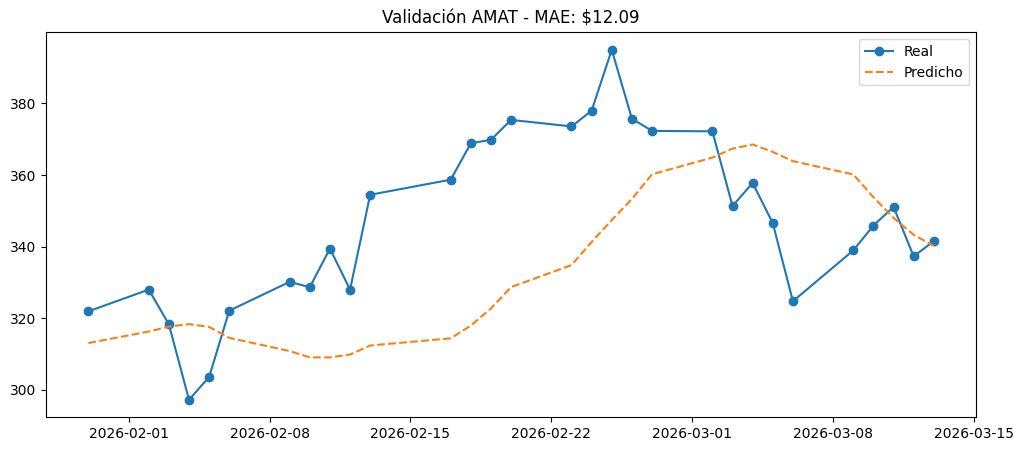


--- PROYECCIÓN PRÓXIMA SEMANA ---
       Fecha  Predicción USD
0 2026-03-16      334.664703
1 2026-03-17      332.759644
2 2026-03-18      331.068817
3 2026-03-19      329.151489
4 2026-03-20      327.511932


In [10]:
# ==============================================================================
# 4. PROYECCIÓN A FUTURO (5 DÍAS)
# ==============================================================================
ultima_ventana = test_scaled[-window:].copy()
proyecciones_usd = []

for i in range(5):
    pred_esc = model.predict(ultima_ventana.reshape(1, window, len(features)), verbose=0)

    # Transformar a USD
    precio_usd = scaler_y.inverse_transform(pred_esc)[0][0]
    proyecciones_usd.append(precio_usd)

    # Actualizar ventana: el nuevo día usa la predicción en el índice 0
    # y mantiene el resto de features del último día conocido
    nuevo_dia = ultima_ventana[-1].copy()
    nuevo_dia[0] = pred_esc[0][0]
    ultima_ventana = np.append(ultima_ventana[1:], [nuevo_dia], axis=0)

# Gráfico
plt.figure(figsize=(12, 5))
plt.plot(fechas_test[-30:], reales_test_usd[-30:], label='Real', marker='o')
plt.plot(fechas_test[-30:], pred_test_usd[-30:], label='Predicho', linestyle='--')
plt.title(f'Validación AMAT - MAE: ${mae_usd:.2f}')
plt.legend()
plt.show()

# Tabla de Proyección
fechas_futuras = pd.date_range(start=df.index[-1], periods=6, freq='B')[1:]
print("\n--- PROYECCIÓN PRÓXIMA SEMANA ---")
print(pd.DataFrame({'Fecha': fechas_futuras, 'Predicción USD': proyecciones_usd}))


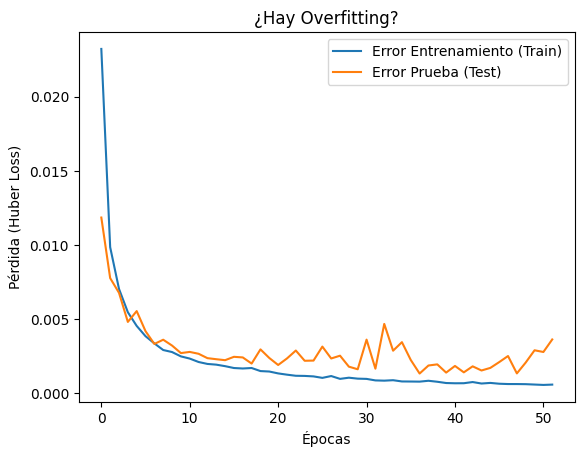

In [11]:
# ==============================================================================
# 5. ASEGURARSE QUE NO HAYA SOBREAJUSTE
# ==============================================================================
# Graficamos los resultados

# Si  las líneas se separan mucho (la de Test queda muy arriba), se sugiere:
# Reducir las neuronas de 128 a 64 o 32.
# Aumentar el valor del Dropout de 0.3 a 0.5.
# Añadir un EarlyStopping para que el entrenamiento se detenga justo antes de que el error de prueba empiece a subir.

# Si reducir neuronas no cierra la brecha, el problema suele estar en la entrada o en la regularización:
# Se debe simplificar la arquitectura al máximo: Probar con una sola capa LSTM. A veces, para series de tiempo cortas (~1500 filas), dos capas LSTM crean demasiada abstracción innecesaria.

import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Error Entrenamiento (Train)')
plt.plot(history.history['val_loss'], label='Error Prueba (Test)')
plt.title('¿Hay Overfitting?')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (Huber Loss)')
plt.legend()
plt.show()


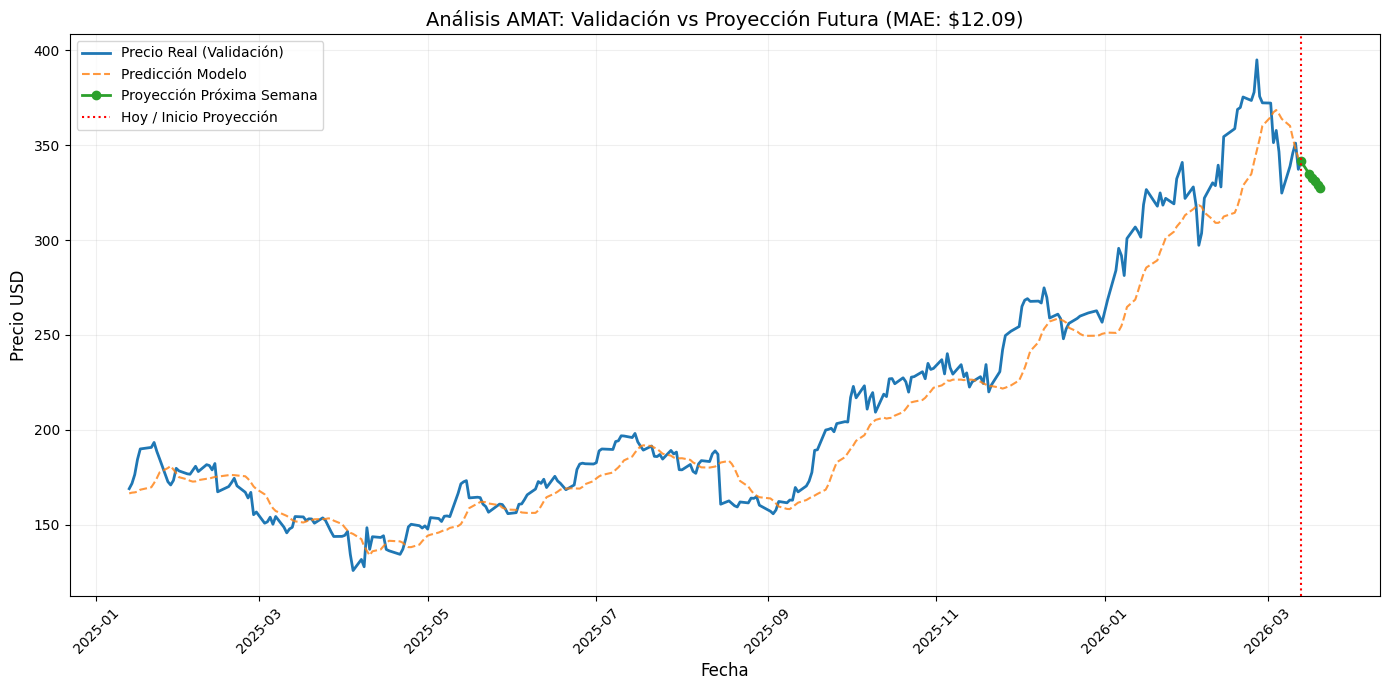


--- RESUMEN DE PROYECCIÓN ---
2026-03-16 | Predicción: $334.66
2026-03-17 | Predicción: $332.76
2026-03-18 | Predicción: $331.07
2026-03-19 | Predicción: $329.15
2026-03-20 | Predicción: $327.51


In [14]:
import matplotlib.pyplot as plt

# ==============================================================================
# 5. GRÁFICO INTEGRADO (VALIDACIÓN + PROYECCIÓN)
# ==============================================================================

plt.figure(figsize=(14, 7))

# 1. Dibujar Precios Reales (Test)
plt.plot(fechas_test, reales_test_usd, label='Precio Real (Validación)', color='#1f77b4', linewidth=2)

# 2. Dibujar Predicciones del Modelo (Test)
plt.plot(fechas_test, pred_test_usd, label='Predicción Modelo', color='#ff7f0e', linestyle='--', alpha=0.8)

# 3. Dibujar Proyección a Futuro
# Concatenamos la última fecha real con las futuras para que la línea no esté "rota"
fechas_proyeccion = [fechas_test[-1]] + list(fechas_futuras)
precios_proyeccion = [reales_test_usd[-1]] + [float(p) for p in proyecciones_usd]

plt.plot(fechas_proyeccion, precios_proyeccion, label='Proyección Próxima Semana', color='#2ca02c', linewidth=2, marker='o')

# Formatos y Estilo
plt.title(f'Análisis AMAT: Validación vs Proyección Futura (MAE: ${mae_usd:.2f})', fontsize=14)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Precio USD', fontsize=12)
plt.axvline(x=fechas_test[-1], color='red', linestyle=':', label='Hoy / Inicio Proyección') # Línea divisoria

plt.legend()
plt.grid(True, alpha=0.2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ==============================================================================
# TABLA FINAL UNIFICADA
# ==============================================================================
print("\n--- RESUMEN DE PROYECCIÓN ---")
for f, p in zip(fechas_futuras, proyecciones_usd):
    print(f"{f.date()} | Predicción: ${float(p):.2f}")
